# Sistem Rekomendasi Resep Makanan

## Pengantar Dataset
Dataset yang digunakan pada project ini adalah Food.com Recipes and Interactions yang bersumber dari platform Food.com dan tersedia melalui Kaggle. Dataset ini berisi lebih dari 230.000 data resep makanan dengan berbagai atribut seperti nama resep, durasi memasak, tags, kandungan nutrisi, jumlah langkah memasak, deskripsi, daftar bahan, dan jumlah bahan. Dataset dipilih karena memiliki jumlah data yang besar, struktur data yang lengkap, serta relevan untuk pengembangan sistem rekomendasi resep makanan berdasarkan karakteristik bahan, waktu memasak, dan informasi nutrisi. Dari sisi etika penggunaan, dataset ini merupakan data publik dan tidak memuat identitas pribadi pengguna, namun tetap memiliki potensi bias karena berasal dari satu platform resep tertentu sehingga preferensi makanan yang ditampilkan dapat lebih merepresentasikan pengguna Food.com.

## Pre Processing Data

#### Import dan load data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("RAW_recipes.csv")

#### Cek struktur dataset
Untuk melihat dimensi dataset (baris dan kolom) dengan atribut `.shape`, kemudian menampilkan 5 baris pertama untuk gambaran awal sebaran kolom

In [3]:
print("Jumlah data:", df.shape)
print("\nData awal:")
df.head()

Jumlah data: (231637, 12)

Data awal:


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [4]:
print(df.dtypes)

name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object


#### Cek missing value

In [5]:
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

Setelah dicek, terdapat missing value pada kolom name sebanyak 1 dan kolom description sebanyak 4979. Untuk menangani hal tersebut, perlu dilakukan penghapusan baris yang pada kolom name kosong dan imputasi konstan pada baris data yang kosong data pada kolom description

Penghapusan data pada baris yang terdapat data kosong di kolom name menggunakan `dropna(subset=["name"])`. Hal ini dilakukan karena judul masakan merupakan identitas utama sebuah resep. Sistem rekomendasi tidak bisa mengidentifikasi atau menyarankan sebuah menu makanan jika menu tidak memiliki nama, sehingga baris ini tidak bisa diimputasi dan harus dihapus.

In [6]:
df.dropna(
    subset=["name"],
    inplace=True
)
df["name"].isnull().sum()

np.int64(0)

Untuk nilai kosong pada baris description dapat ditangani menggunakan imputasi konstan dengan mengisi nilai kosong menjadi "No description" menggunakan fungsi `.fillna()`. Data kosong pada kolom description masih dapat diimputasi karena dalam baris data tersebut masih ada kolom yang menyimpan informasi numerik yang valid. Data kosong di kolom description terdapat 4979 baris. Apabila dihapus, model akan kehilangan banyak data latih potensial.

In [7]:
df["description"] = df[
    "description"
].fillna(
    "No description"
)

In [8]:
df.isnull().sum()

name              0
id                0
minutes           0
contributor_id    0
submitted         0
tags              0
nutrition         0
n_steps           0
steps             0
description       0
ingredients       0
n_ingredients     0
dtype: int64

setelah diimputasi dan hapus data, saat dicek sudah tidak ada data kosong

Kemudian cek juga apa kah data ada yang terduplikasi atau tidak dengan fungsi `.duplicated`.

In [9]:
df.duplicated().sum()

np.int64(0)

Dari hasil terlihat tidak ada data yang terduplikasi

---
##### unduh dataset yang sudah dibersihkan


In [10]:
df.to_csv(
    "dataset_clean.csv",
    index=False
)


---

#### Parsing
Pada dataset, terdapat kolom yang menyimpan data dalam bentuk string. Jika diproses, python akan menganggapnya sebagai karakter biasa dan tidak dapat membaca angka angka gizi atau jumlah bahan di dalamnya.

Kolom yang merupakan terbaca string nakun harusnya dibaca sebagai array adalah kolom tags, nutrition, steps, dan ingredients. Bukti ini terlihat nyata dari hasil pengecekan tipe data menggunakan perintah df.dtypes yang menunjukkan bahwa keempat kolom tersebut berlabel object.

In [11]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


Untuk menangani ini, dilakukan parsing dengan fungsi `ast.literal_eval`. String text nantinya akan diubah menjadi list (array).

In [12]:
import ast

df["nutrition"] = df[
    "nutrition"
].apply(
    ast.literal_eval
)

df["ingredients"] = df[
    "ingredients"
].apply(
    ast.literal_eval
)

df["tags"] = df[
    "tags"
].apply(
    ast.literal_eval
)

df["steps"] = df[
    "steps"
].apply(
    ast.literal_eval
)

In [13]:
print(type(df["nutrition"][0]))
print(type(df["ingredients"][0]))
print(type(df["tags"][0]))
print(type(df["steps"][0]))

<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>


---

#### EDA
Exploratory Data Analysis (EDA) dilakukan untuk mengenali karakterisitik sebaran data, mendeteksi outliers, serta melihat hubungan antar fitur sebelum data di training

In [14]:
print("Jumlah data:", df.shape)

Jumlah data: (231636, 12)


Sebelum melakukan visualisasi histogram, dilakukan analisis terhadap karakteristik statistik deskriptif awal. Langkah ini dilakukan untuk memetakan rentang nilai minimum, kuartil, hingga nilai maksimum dari fitur-fitur numerik yang tersedia pada dataset.

In [15]:
df.describe()

,id,minutes,contributor_id,n_steps,n_ingredients
count,231636.000000,2.316360e+05,2.316360e+05,231636.000000,231636.000000
mean,222014.077639,9.398587e+03,5.534906e+06,9.765516,9.051149
std,141206.613497,4.461973e+06,9.979162e+07,5.995136,3.734803
min,38.000000,0.000000e+00,2.700000e+01,0.000000,1.000000
25%,99943.750000,2.000000e+01,5.690500e+04,6.000000,6.000000
50%,207248.500000,4.000000e+01,1.736140e+05,9.000000,9.000000
75%,333815.250000,6.500000e+01,3.982750e+05,12.000000,11.000000
max,537716.000000,2.147484e+09,2.002290e+09,145.000000,43.000000


Terdapat 3 fitur numerik, yaitu `minutes`, `n_ingredient`, dan `n_step`.

Fitur durasi memasak (minutes) memiliki nilai median (kuartil 50%), yaitu 40 menit, dengan kuartil 75% berada di angka 65 menit. Namun, pada nilai maksimum (max), ditemukan angka pencilan yang sangat tidak masuk akal sebesar 2.147484e+09 (lebih dari 2 miliar menit). Hal ini mengonfirmasi adanya human error atau data rusak (corrupted data) saat penginputan dari platform aslinya. Oleh karena itu, histogram khusus untuk minutes wajib dibuat untuk melihat secara visual seberapa parah tingkat kecondongan (skewness) distribusi data akibat hantaman pencilan raksasa tersebut.

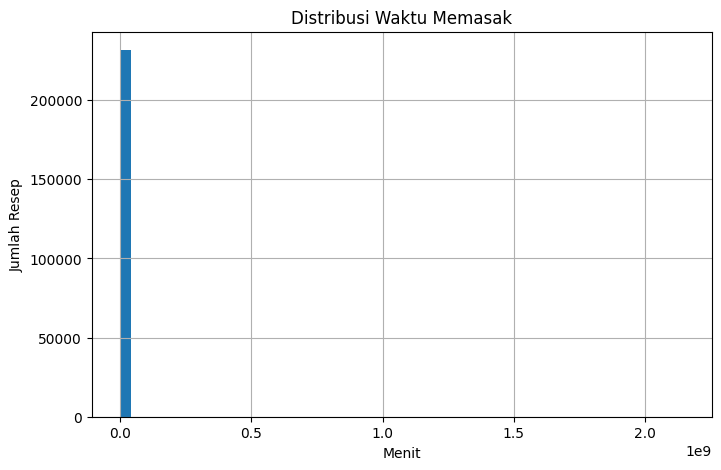

In [16]:
plt.figure(figsize=(8,5))

df["minutes"].hist(
    bins=50
)

plt.title("Distribusi Waktu Memasak")
plt.xlabel("Menit")
plt.ylabel("Jumlah Resep")

plt.show()

Grafik histogram untuk fitur minutes menunjukkan penumpukan data yang sangat ekstrem di pojok kiri dekat angka 0, sementara sumbu X melar sangat jauh hingga skala $2.0 \times 10^9$ (lebih dari 2 miliar menit). Fenomena visual yang sangat condong (highly skewed) ini menjadi bukti konkret adanya anomali data raksasa atau human error pada proses input data mentah dari platform aslinya.



---



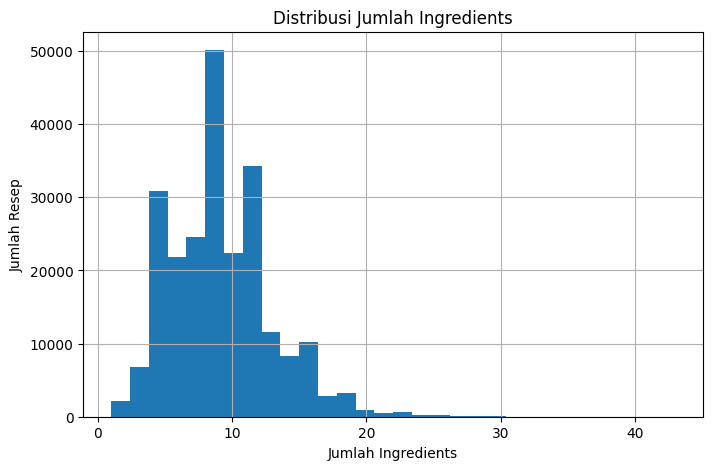

In [17]:
plt.figure(figsize=(8,5))

df["n_ingredients"].hist(
    bins=30
)

plt.title("Distribusi Jumlah Ingredients")
plt.xlabel("Jumlah Ingredients")
plt.ylabel("Jumlah Resep")

plt.show()

Grafik histogram untuk fitur n_ingredients membentuk kurva yang mendekati distribusi normal (bell-shaped curve) dengan kecondongan tipis ke arah kanan (right-skewed). Pola data terlihat sangat sehat dan masuk akal secara fisis, di mana puncak frekuensi tertinggi (modus) berada tepat pada angka 9 jenis bahan baku, dengan mayoritas sebaran data resep masakan berpusat di kisaran 5 hingga 12 bahan. Informasi sebaran yang konsisten ini membuktikan bahwa dataset memiliki karakteristik konten yang baik untuk sistem rekomendasi, sehingga model dapat dengan mudah memetakan profil makanan kategori "simpel" atau "kompleks" berdasarkan kuantitas bahan dasarnya.



---



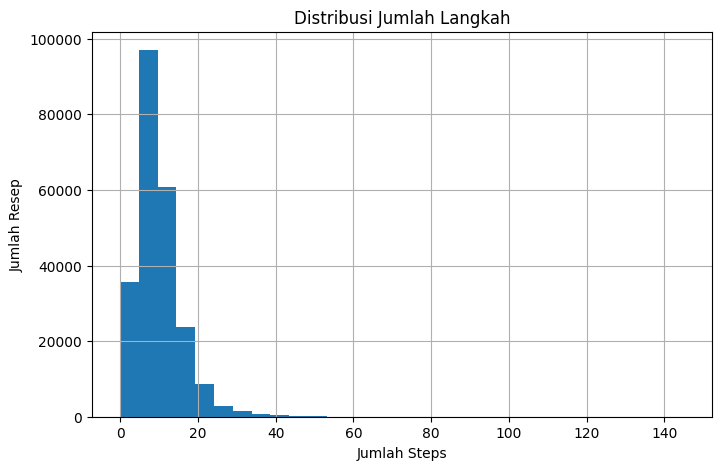

In [18]:
plt.figure(figsize=(8,5))

df["n_steps"].hist(
    bins=30
)

plt.title("Distribusi Jumlah Langkah")
plt.xlabel("Jumlah Steps")
plt.ylabel("Jumlah Resep")

plt.show()

Grafik histogram untuk fitur n_steps menunjukkan pola distribusi yang condong ke kanan (right-skewed distribution), di mana mayoritas data menumpuk padat pada area kiri grafik dan perlahan melandai seiring bertambahnya jumlah instruksi. Sebagian besar resep di dalam dataset terdeteksi membutuhkan tingkat kerumitan yang praktis, yakni berkisar antara 5 hingga 10 langkah pembuatan saja, sebelum akhirnya frekuensi resep menurun drastis secara eksponensial setelah melewati angka 20 langkah.


---

Selanjutnya, dilakukan proses validasi data konkret menggunakan perintah pengurutan (.sort_values()) untuk memverifikasi nilai-resep paling ekstrem di batas bawah dan batas atas dataset—yaitu memeriksa apakah resep dengan durasi 0 menit murni merupakan hidangan mentah (seperti jus atau salad) dan resep dengan 43 bahan memang logis di dunia nyata

In [19]:
df[
    ["name","minutes"]
].sort_values(
    by="minutes"
).head(10)

,name,minutes
67883,cucumber dill dip,0
67871,cucumber cocktail,0
67817,cucumber and avocado salad,0
215787,tortilla beef,0
46713,chicken zucchini casserole,0
187900,six layer dinner,0
17796,barbecued garlic shrimp,0
17770,barbecued chicken thighs au vin,0
17665,barbecue sauce 1,0
17895,barbecued turkey on a bun,0


In [20]:
df[
    ["name","n_ingredients"]
].sort_values(
    by="n_ingredients",
    ascending=False
).head(10)

,name,n_ingredients
2162,a to z bread,43
230245,z best two faced jerk,40
139659,morton thompson turkey,40
116744,kato s garage style tomato sauce meatba...,39
18352,basic fried rice with variations,38
203614,sunday supper taco salad bowls tacos,37
119626,land and sea white meat version of surf and turf,37
71669,dhansak with brown rice,36
55542,coconut chicken fingers with mango rum salsa,35
105723,hillbilly bean soup,35


---
Setelah memvalidasi data ekstrem melalui pengurutan tersebut, tahapan EDA dilanjutkan ke pembuatan Boxplot khusus untuk kolom waktu memasak (minutes).

Visualisasi menggunakan Boxplot ini difokuskan hanya pada fitur minutes karena kolom tersebut memiliki kecenderungan anomali pencilan (outlier) yang paling destruktif dibandingkan kolom jumlah langkah atau jumlah bahan yang secara logika memiliki batas maksimum normal. Grafik boxplot menampilkan sebaran ribuan titik pencilan yang melambung sangat jauh di atas nilai kuartil atas hingga menyentuh skala miliaran menit, yang secara fisis membuktikan adanya variasi data durasi memasak yang sangat jomplang akibat human error saat penginputan di platform aslinya.

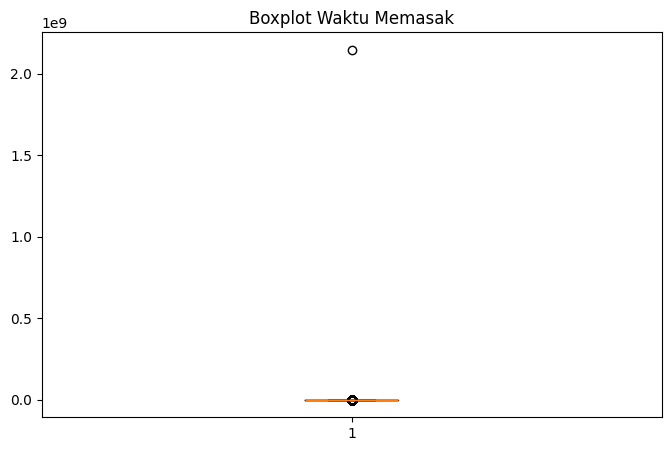

In [21]:
# boxplot
plt.figure(figsize=(8,5))

plt.boxplot(
    df["minutes"]
)

plt.title("Boxplot Waktu Memasak")

plt.show()

Grafik boxplot menunjukkan kotak data utama terkompresi hingga membentuk satu garis tipis di paling bawah akibat tertekan oleh keberadaan satu titik pencilan (extreme outlier) raksasa yang melambung ekstrem hingga skala 2 miliar menit

Kemudian selanjutnya pembuatan heatmap untuk mengukur kekuatan hubungan linear antar-variabel numerik. Grafik ini dibatasi hanya menggunakan 6 fitur inti (minutes, n_steps, n_ingredients, calories, fat, tag_count) untuk menghindari korelasi ganda dari unsur gizi sejenis seperti lemak jenuh, karbohidrat, atau gula, sekaligus menjaga keterbacaan grafik agar tidak terlalu padat sehingga pola hubungan antar-kelompok karakteristik utama resep dapat diinterpretasikan secara fokus dan optimal.

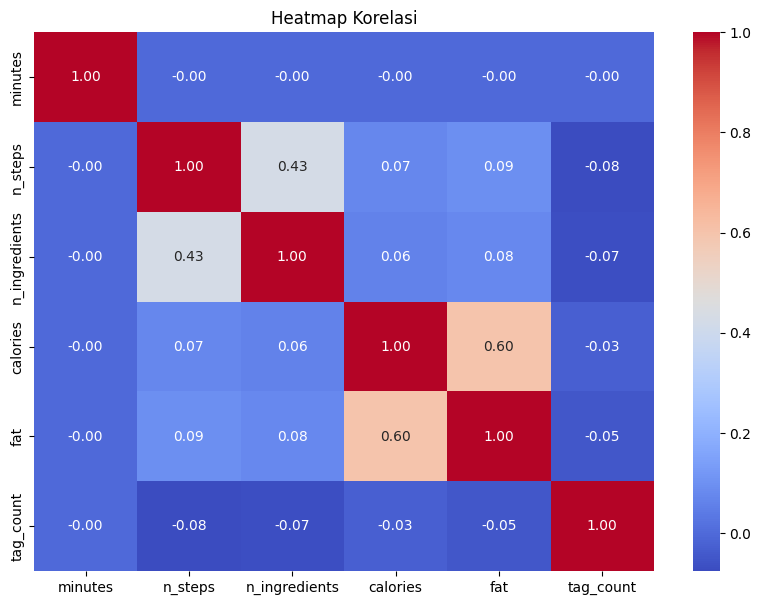

In [24]:
numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients",
    "calories",
    "fat",
    "tag_count"
]


# df["calories"] = df["nutrition"].apply(lambda x: x[0])
# df["fat"] = df["nutrition"].apply(lambda x: x[1])
# df["tag_count"] = df["tags"].apply(len)

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Heatmap Korelasi"
)

plt.show()

---
#### feature engineering
Tahap Feature Engineering dilakukan untuk memecah kolom nutrition menjadi 7 indikator zat gizi mandiri (kalori, lemak, gula, sodium, protein, lemak jenuh, dan karbohidrat) serta mengekstrak metrik kuantitas fisik hidangan seperti jumlah tag, jumlah bahan, jumlah langkah, hingga panjang karakter judul dan deskripsi resep, di mana langkah ini sangat urgen untuk mentransformasikan struktur gumpalan teks mentah menjadi sekumpulan matriks prediktor numerik ($X$) yang seragam agar model dapat menghitung bobot kemiripan profil nutrisi dan kompleksitas resep secara akurat

In [25]:
# kalori
df["calories"] = df["nutrition"].apply(
    lambda x: x[0]
)

print(
    df[
        ["name", "calories"]
    ].head()
)

                                         name  calories
0  arriba   baked winter squash mexican style      51.5
1            a bit different  breakfast pizza     173.4
2                   all in the kitchen  chili     269.8
3                          alouette  potatoes     368.1
4          amish  tomato ketchup  for canning     352.9


In [26]:
# nutrisi
df["fat"] = df["nutrition"].apply(
    lambda x: x[1]
)

print(
    df[
        ["name", "fat"]
    ].head()
)

                                         name   fat
0  arriba   baked winter squash mexican style   0.0
1            a bit different  breakfast pizza  18.0
2                   all in the kitchen  chili  22.0
3                          alouette  potatoes  17.0
4          amish  tomato ketchup  for canning   1.0


In [27]:
# gula
df["sugar"] = df["nutrition"].apply(
    lambda x: x[2]
)

print(
    df[
        ["name", "sugar"]
    ].head()
)

                                         name  sugar
0  arriba   baked winter squash mexican style   13.0
1            a bit different  breakfast pizza    0.0
2                   all in the kitchen  chili   32.0
3                          alouette  potatoes   10.0
4          amish  tomato ketchup  for canning  337.0


In [28]:
# sodium
df["sodium"] = df["nutrition"].apply(
    lambda x: x[3]
)

print(
    df[
        ["name", "sodium"]
    ].head()
)

                                         name  sodium
0  arriba   baked winter squash mexican style     0.0
1            a bit different  breakfast pizza    17.0
2                   all in the kitchen  chili    48.0
3                          alouette  potatoes     2.0
4          amish  tomato ketchup  for canning    23.0


In [29]:
# protein
df["protein"] = df["nutrition"].apply(
    lambda x: x[4]
)

print(
    df[
        ["name", "protein"]
    ].head()
)

                                         name  protein
0  arriba   baked winter squash mexican style      2.0
1            a bit different  breakfast pizza     22.0
2                   all in the kitchen  chili     39.0
3                          alouette  potatoes     14.0
4          amish  tomato ketchup  for canning      3.0


In [30]:
#saturated fat
df["saturated_fat"] = df["nutrition"].apply(
    lambda x: x[5]
)

print(
    df[
        ["name", "saturated_fat"]
    ].head()
)

                                         name  saturated_fat
0  arriba   baked winter squash mexican style            0.0
1            a bit different  breakfast pizza           35.0
2                   all in the kitchen  chili           27.0
3                          alouette  potatoes            8.0
4          amish  tomato ketchup  for canning            0.0


In [31]:
# karbohidrat
df["carbohydrates"] = df["nutrition"].apply(
    lambda x: x[6]
)

print(
    df[
        ["name", "carbohydrates"]
    ].head()
)

                                         name  carbohydrates
0  arriba   baked winter squash mexican style            4.0
1            a bit different  breakfast pizza            1.0
2                   all in the kitchen  chili            5.0
3                          alouette  potatoes           20.0
4          amish  tomato ketchup  for canning           28.0


In [32]:
# jumlah tag
df["tag_count"] = df["tags"].apply(
    len
)

print(
    df[
        ["name", "tag_count"]
    ].head()
)

                                         name  tag_count
0  arriba   baked winter squash mexican style         20
1            a bit different  breakfast pizza         20
2                   all in the kitchen  chili          9
3                          alouette  potatoes         30
4          amish  tomato ketchup  for canning         21


In [33]:
# jumlah bahan
df["ingredient_count"] = df[
    "ingredients"
].apply(
    len
)

print(
    df[
        ["name", "ingredient_count"]
    ].head()
)

                                         name  ingredient_count
0  arriba   baked winter squash mexican style                 7
1            a bit different  breakfast pizza                 6
2                   all in the kitchen  chili                13
3                          alouette  potatoes                11
4          amish  tomato ketchup  for canning                 8


In [34]:
#jumlah langkah
df["step_count"] = df[
    "steps"
].apply(
    len
)

print(
    df[
        ["name", "step_count"]
    ].head()
)

                                         name  step_count
0  arriba   baked winter squash mexican style          11
1            a bit different  breakfast pizza           9
2                   all in the kitchen  chili           6
3                          alouette  potatoes          11
4          amish  tomato ketchup  for canning           5


In [35]:
# panjang nama resep
df["name_length"] = df[
    "name"
].astype(str).str.len()

print(
    df[
        ["name", "name_length"]
    ].head()
)

                                         name  name_length
0  arriba   baked winter squash mexican style           42
1            a bit different  breakfast pizza           32
2                   all in the kitchen  chili           25
3                          alouette  potatoes           18
4          amish  tomato ketchup  for canning           34


In [36]:
# panjang deskripsi
df["description_length"] = df[
    "description"
].astype(str).str.len()

print(
    df[
        ["name", "description_length"]
    ].head()
)

                                         name  description_length
0  arriba   baked winter squash mexican style                 194
1            a bit different  breakfast pizza                 180
2                   all in the kitchen  chili                 295
3                          alouette  potatoes                 233
4          amish  tomato ketchup  for canning                 183


In [37]:
# cek hasil
print(
    df[
        [
            "name",
            "calories",
            "fat",
            "sugar",
            "protein",
            "tag_count",
            "ingredient_count",
            "step_count",
            "name_length"
        ]
    ].head()
)

                                         name  calories   fat  sugar  protein  \
0  arriba   baked winter squash mexican style      51.5   0.0   13.0      2.0   
1            a bit different  breakfast pizza     173.4  18.0    0.0     22.0   
2                   all in the kitchen  chili     269.8  22.0   32.0     39.0   
3                          alouette  potatoes     368.1  17.0   10.0     14.0   
4          amish  tomato ketchup  for canning     352.9   1.0  337.0      3.0   

   tag_count  ingredient_count  step_count  name_length  
0         20                 7          11           42  
1         20                 6           9           32  
2          9                13           6           25  
3         30                11          11           18  
4         21                 8           5           34  


---
#### encoding
encoding digunakan untuk mengubah data kategori pada main_tag menjadi indeks angka numerik shingga bisa diproses secara matematis oleh algoritma

Sebelumnya dilakukan ektrasi `tag` dengan fungsi `lamda` untuk membentuk kolom kategori baru bernama `main_tag`

In [38]:
df["main_tag"] = df["tags"].apply(
    lambda x: x[0] if len(x) > 0 else "unknown"
)

print(
    df[
        ["name", "main_tag"]
    ].head()
)

                                         name            main_tag
0  arriba   baked winter squash mexican style  60-minutes-or-less
1            a bit different  breakfast pizza  30-minutes-or-less
2                   all in the kitchen  chili        time-to-make
3                          alouette  potatoes  60-minutes-or-less
4          amish  tomato ketchup  for canning           weeknight


Selanjutnya menerapkan labelencoder untuk mengubah string teks menjadi format angka indeks numerik agar bisa diproses secara matematis oleh algoritma

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["main_tag"] = le.fit_transform(
    df["main_tag"]
)

print(
    df[
        ["name", "main_tag"]
    ].head()
)

                                         name  main_tag
0  arriba   baked winter squash mexican style         3
1            a bit different  breakfast pizza         2
2                   all in the kitchen  chili        23
3                          alouette  potatoes         3
4          amish  tomato ketchup  for canning        24


mapping data untuk menampilkan pemetaan label asli dengan hasil angka konversinya

In [41]:
mapping = dict(
    zip(
        le.classes_,
        le.transform(le.classes_)
    )
)

print(mapping)

{'': np.int64(0), '15-minutes-or-less': np.int64(1), '30-minutes-or-less': np.int64(2), '60-minutes-or-less': np.int64(3), 'Throw the ultimate fiesta with this sopaipillas recipe from Food.com.': np.int64(4), 'bacon': np.int64(5), 'celebrity': np.int64(6), 'chicken': np.int64(7), 'course': np.int64(8), 'cuisine': np.int64(9), 'curries': np.int64(10), 'danish': np.int64(11), 'dietary': np.int64(12), 'ham': np.int64(13), 'healthy': np.int64(14), 'lactose': np.int64(15), 'less_thansql:name_topics_of_recipegreater_than': np.int64(16), 'low-protein': np.int64(17), 'main-ingredient': np.int64(18), 'number-of-servings': np.int64(19), 'occasion': np.int64(20), 'oysters': np.int64(21), 'preparation': np.int64(22), 'time-to-make': np.int64(23), 'weeknight': np.int64(24)}


#### Scaling
scalling dilakukan untuk menyetarakan skala rentang nilai dari seluruh kolom numerik agar algoritma tidak bias bada fitur yang memiliki angka besar saja.

tahap ini menggunakan standardscaler untuk meredam pencilan ekstrem durasi memasak tanpa merusak variasi pola data resep yang lain. kolom prdiktor dipisah, kemudian dihitung nilai rata-rata dan standar devisiasinya, kemudian seluruh angka dikonversi kedalam skala standar baru

In [42]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "minutes",
    "n_steps",
    "n_ingredients",
    "calories",
    "fat",
    "sugar",
    "sodium",
    "protein",
    "saturated_fat",
    "carbohydrates",
    "tag_count",
    "ingredient_count",
    "step_count",
    "name_length",
    "description_length",
    "main_tag"
]

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[numeric_cols] = scaler.fit_transform(
    df_scaled[numeric_cols]
)

print(
    df_scaled[
        numeric_cols
    ].head()
)

    minutes   n_steps  n_ingredients  calories       fat     sugar    sodium  \
0 -0.002094  0.205915      -0.549200 -0.355076 -0.463765 -0.089112 -0.228458   
1 -0.002100 -0.127690      -0.816952 -0.252614 -0.232395 -0.105360 -0.099632   
2 -0.002077 -0.628097       1.057314 -0.171586 -0.180980 -0.065364  0.135285   
3 -0.002096  0.205915       0.521809 -0.088961 -0.245249 -0.092861 -0.213302   
4 -0.002064 -0.794899      -0.281448 -0.101737 -0.450911  0.315847 -0.054164   

    protein  saturated_fat  carbohydrates  tag_count  ingredient_count  \
0 -0.558930      -0.464077      -0.141283   0.292629         -0.549200   
1 -0.216889      -0.107790      -0.177947   0.292629         -0.816952   
2  0.073847      -0.189227      -0.129062  -1.225801          1.057314   
3 -0.353705      -0.382640       0.054257   1.673020          0.521809   
4 -0.541828      -0.464077       0.152028   0.430668         -0.281448   

   step_count  name_length  description_length  main_tag  
0    0.205915  

#### train test split
data yang ada kemudian dipisah menjadi 80 untuk training dan 20 untuk testing. 80:20 dipilih karena menjadi standar umum dalam pemodelan. parameter random_state=42 disematkan untuk mengunci pengacakan data dan hasil pembagian tetap konsisten

In [43]:
from sklearn.model_selection import train_test_split

X = df_scaled[
    [
        "minutes",
        "n_steps",
        "n_ingredients",
        "calories",
        "fat",
        "sugar",
        "sodium",
        "protein",
        "saturated_fat",
        "carbohydrates",
        "tag_count",
        "ingredient_count",
        "step_count",
        "name_length",
        "description_length"
    ]
]

y = df_scaled["main_tag"]

# split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (185308, 15)
Test : (46328, 15)


#### save csv

In [44]:
df_scaled.to_csv(
    "food_recommendation_scaaling.csv",
    index=False
)


---
---
---

## Modeling

### Content-Based Filtering (Cosine Similarity)

In [45]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

df_scaled = pd.read_csv("food_recommendation_scaaling.csv")

features = [
    "minutes",
    "calories",
    "fat",
    "ingredient_count",
    "tag_count",
    "main_tag"
]

X = df_scaled[features]

cosine_sim = cosine_similarity(X)

print("Matrix similarity berhasil dibuat")

MemoryError: Unable to allocate 400. GiB for an array with shape (231636, 231636) and data type float64

In [ ]:
def recommend_cosine(recipe_name, n=5):

    idx = df[
        df["name"].str.lower() ==
        recipe_name.lower()
    ].index

    if len(idx) == 0:
        return "Recipe not found"

    idx = idx[0]

    scores = list(
        enumerate(cosine_sim[idx])
    )

    scores = sorted(
        scores,
        key=lambda x: x[1],
        reverse=True
    )

    scores = scores[1:n+1]

    recipe_idx = [
        i[0] for i in scores
    ]

    return df[
        [
            "name",
            "minutes",
            "ingredient_count",
            "calories"
        ]
    ].iloc[recipe_idx]

In [ ]:
df["name"].head(10)

### KNN